
# Sarcasm Detection Tutorial — CSV to Evaluation (CNN fallback-ready)
**Last updated:** 2025-10-12 13:18

Notebook ini dibuat untuk pembelajaran mahasiswa: mulai dari membuat/menyiapkan dataset **CSV**, memuat data, preprocessing, training model, hingga **evaluasi**.  
Secara otomatis:
- Jika **TensorFlow** tersedia di environment Anda → kita pakai **CNN 1D** untuk teks.
- Jika tidak tersedia → fallback ke **TF-IDF + Logistic Regression** (sklearn).

> **Catatan:** Notebook ini juga membuat dataset contoh `sarcasm_toy.csv` agar dapat langsung dicoba. Anda bisa menggantinya dengan dataset Anda sendiri selama memiliki kolom `text` (teks) dan `label` (0=non-sarcastic, 1=sarcastic).



## Tujuan Pembelajaran
1. Memahami alur kerja NLP supervised (klasifikasi teks) dari CSV → evaluasi.
2. Menerapkan split train/valid/test yang benar.
3. Mencoba dua jalur model:
   - CNN 1D (jika TensorFlow tersedia)
   - TF‑IDF + Logistic Regression (fallback)
4. Menghasilkan metrik evaluasi dan confusion matrix.


In [3]:

# Install (opsional) — jalankan hanya jika ingin mencoba CNN dengan TensorFlow
# !pip install -q tensorflow

import os, sys, random, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Matplotlib version:", plt.matplotlib.__version__)


Python: 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]
Matplotlib version: 3.10.6



## 1) (Opsional) Membuat Dataset Contoh → `sarcasm_toy.csv`
Jalankan sel ini untuk membuat dataset mainan 400 baris (200 sarkastik, 200 non-sarkastik).  
Jika sudah punya CSV sendiri, **boleh lewati** dan atur `csv_path` pada sel berikutnya.


In [ ]:
import pandas as pd
import random

random.seed(42)

sarcastic_templates = [
    "Oh great, another {thing}, just what I needed.",
    "Yeah, because {thing} always solves everything.",
    "Fantastic, I {action} for this moment.",
    "Love it when {event} happens, best day ever.",
    "Sure, {thing} is definitely my favorite.",
    "Amazing, I totally failed because I'm a genius.",
    "Perfect timing, as always.",
    "Wow, who could have guessed that {thing}?",
    "Nice, nothing like {event} to brighten my day.",
    "Just wonderful, my {thing} broke again."
]

nonsarcastic_templates = [
    "I really enjoy {thing}.",
    "This is a great day for {action}.",
    "I appreciate your help with {thing}.",
    "The {event} went well today.",
    "I love spending time on {thing}.",
    "Thank you for organizing the {event}.",
    "I learned a lot from {thing}.",
    "This will help me {action}.",
    "I am happy about the {event}.",
    "Looking forward to {action} tomorrow."
]

things = ["meetings", "deadlines", "coffee", "rain", "traffic", "group projects", "homework", "updates", "emails", "bugs"]
actions = ["studying", "working", "practicing", "learning", "coding", "reading", "writing", "training"]
events = ["power outage", "system update", "network downtime", "team meeting", "exam", "presentation", "deployment"]

def fill_template(t):
    return t.format(
        thing=random.choice(things),
        action=random.choice(actions),
        event=random.choice(events)
    )

rows = []
for _ in range(200):  # sarcastic
    rows.append({"text": fill_template(random.choice(sarcastic_templates)), "label": 1})
for _ in range(200):  # non-sarcastic
    rows.append({"text": fill_template(random.choice(nonsarcastic_templates)), "label": 0})

random.shuffle(rows)
df = pd.DataFrame(rows)

csv_path = "sarcasm_toy.csv" 
df.to_csv(csv_path, index=False)
print("Saved:", csv_path, "rows:", len(df))
df.head()

Saved: sarcasm_toy.csv rows: 400


,text,label
0,"Perfect timing, as always.",1
1,"Oh great, another deadlines, just what I needed.",1
2,This will help me reading.,0
3,"Perfect timing, as always.",1
4,I am happy about the power outage.,0



## 2) Load CSV & Inspeksi Awal
Ubah `csv_path` ke file Anda jika tidak memakai dataset contoh.


In [6]:

import pandas as pd

csv_path = "sarcasm_toy.csv"

data = pd.read_csv(csv_path)
print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("\nLabel distribution:\n", data["label"].value_counts())
data.sample(10, random_state=0)


Shape: (400, 2)
Columns: ['text', 'label']

Label distribution:
 label
1    200
0    200
Name: count, dtype: int64


,text,label
132,"Yeah, because meetings always solves everything.",1
309,"Sure, coffee is definitely my favorite.",1
341,"Love it when team meeting happens, best day ever.",1
196,"Love it when team meeting happens, best day ever.",1
246,"Fantastic, I working for this moment.",1
60,"Fantastic, I studying for this moment.",1
155,"Yeah, because emails always solves everything.",1
261,"Nice, nothing like presentation to brighten my...",1
141,Looking forward to coding tomorrow.,0
214,This will help me reading.,0



## 3) Train / Validation / Test Split
Menggunakan stratified split agar rasio label seimbang di tiap subset.


In [7]:

from sklearn.model_selection import train_test_split

X = data["text"].astype(str).values
y = data["label"].values

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 280
Val size: 60
Test size: 60



## 4) Preprocessing
- **CNN path:** Tokenizer + padding sequence (butuh TensorFlow).  
- **Fallback path:** TF‑IDF bigram + Logistic Regression.


In [8]:
use_tf = False
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    use_tf = True
    print("TensorFlow detected — CNN path will be used.")
except Exception as e:
    print("TensorFlow not available — using classical ML pipeline (TF-IDF + LogisticRegression).")

max_words = 5000
max_len = 30

if use_tf:
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)

    X_train_proc = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post", truncating="post")
    X_val_proc   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=max_len, padding="post", truncating="post")
    X_test_proc  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=max_len, padding="post", truncating="post")
    vocab_size = min(max_words, len(tokenizer.word_index) + 1)
    print("Vocab size:", vocab_size, "Max len:", max_len)
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), lowercase=True)
    X_train_proc = tfidf.fit_transform(X_train)
    X_val_proc   = tfidf.transform(X_val)
    X_test_proc  = tfidf.transform(X_test)
    print("TF-IDF features:", X_train_proc.shape)


TensorFlow detected — CNN path will be used.
Vocab size: 110 Max len: 30



## 5) Membangun Model
- **CNN:** Embedding → Conv1D → GlobalMaxPool → Dense.
- **Fallback:** Logistic Regression.


In [9]:
if use_tf:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_len,)),  # gunakan input_shape, bukan input_length
        Conv1D(filters=128, kernel_size=3, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # pastikan model dibangun (khusus beberapa versi TF)
    model.build(input_shape=(None, max_len))  # tambahkan ini jika tetap muncul 0 param
    model.summary()

else:
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression(max_iter=200)
    print(model)

c:\Users\IMAM\miniforge3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,065 (156.50 KB)

 Trainable params: 40,065 (156.50 KB)

 Non-trainable params: 0 (0.00 B)


## 6) Training


In [10]:
history = None

if use_tf:
    y_train_np = np.array(y_train)
    y_val_np   = np.array(y_val)
    history = model.fit(
        X_train_proc, y_train_np,
        validation_data=(X_val_proc, y_val_np),
        epochs=10,
        batch_size=32,
        verbose=1
    )
else:
    model.fit(X_train_proc, y_train)
    print("Training complete (classical ML).")


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7393 - loss: 0.6772 - val_accuracy: 1.0000 - val_loss: 0.6419
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9857 - loss: 0.6156 - val_accuracy: 1.0000 - val_loss: 0.5457
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9964 - loss: 0.4906 - val_accuracy: 1.0000 - val_loss: 0.3769
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.3011 - val_accuracy: 1.0000 - val_loss: 0.1710
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9964 - loss: 0.1267 - val_accuracy: 1.0000 - val_loss: 0.0448
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0326 - val_accuracy: 1.0000 - val_loss: 0.0097
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0014



## 7) Evaluasi — Akurasi, Classification Report, Confusion Matrix


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        30
           1     1.0000    1.0000    1.0000        30

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60

Confusion Matrix:
 [[30  0]
 [ 0 30]]


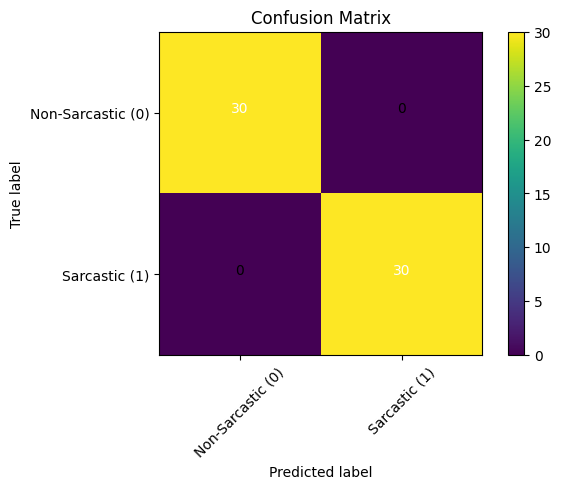

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

if use_tf:
    y_pred_prob = model.predict(X_test_proc).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
else:
    y_pred = model.predict(X_test_proc)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix (matplotlib, no seaborn)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Non-Sarcastic (0)', 'Sarcastic (1)'], rotation=45)
plt.yticks(tick_marks, ['Non-Sarcastic (0)', 'Sarcastic (1)'])
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



## 8) (Opsional) Learning Curves — hanya untuk jalur CNN


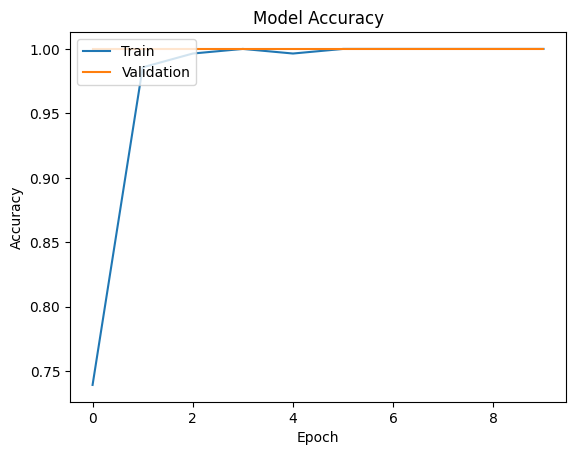

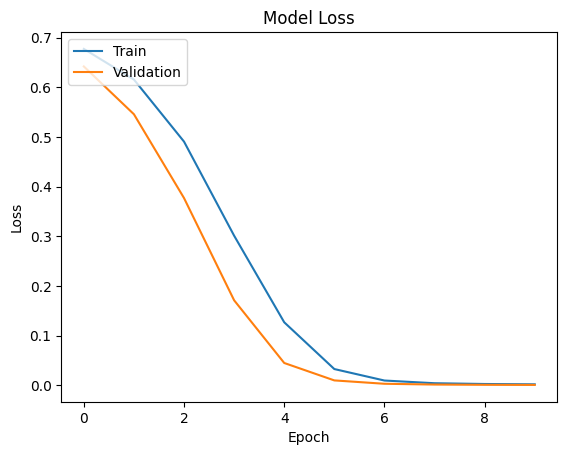

In [12]:
if use_tf and history is not None:
    # Accuracy
    plt.figure()
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title("Model Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title("Model Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")
    plt.show()
else:
    print("Learning curves tersedia bila menggunakan TensorFlow (CNN).")



## 9) Demo Prediksi Kalimat Baru
Ubah daftar kalimat di bawah ini, lalu jalankan untuk melihat prediksi.


In [13]:
sentences = [
    "Oh great, another meeting at 7am, my favorite.",
    "I love learning new things in class.",
    "Fantastic, the network is down again.",
    "Thank you for your help!"
]

if use_tf:
    seqs = [sent.split() for sent in sentences]  # only to inspect
    X_new = pad_sequences(tokenizer.texts_to_sequences(sentences), maxlen=30, padding="post", truncating="post")
    probs = model.predict(X_new).ravel()
    preds = (probs >= 0.5).astype(int)
else:
    X_new = tfidf.transform(sentences)
    preds = model.predict(X_new)

for s, p in zip(sentences, preds):
    print(f"{p}\t{s}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1	Oh great, another meeting at 7am, my favorite.
0	I love learning new things in class.
0	Fantastic, the network is down again.
0	Thank you for your help!



## Tugas Lanjutan
- Ganti dataset dengan data **Album Kisah Wayang** (Dataset Sentiment) . Pastikan pembersihan teks yang memadai.